<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/11_benchmark_suite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_124304
                model            task   roc_auc  precision    recall        f1
3          CAT_Hybrid  scam_detection  0.941534   0.832598  0.827819  0.830201
1        RandomForest  scam_detection  0.910839   0.811874  0.766374  0.788468
0  LogisticRegression  scam_detection  0.700587   0.648363  0.621877  0.634844
2                 SVM  scam_detection  0.659612   0.659729  0.642134  0.650813
Benchmark Completed


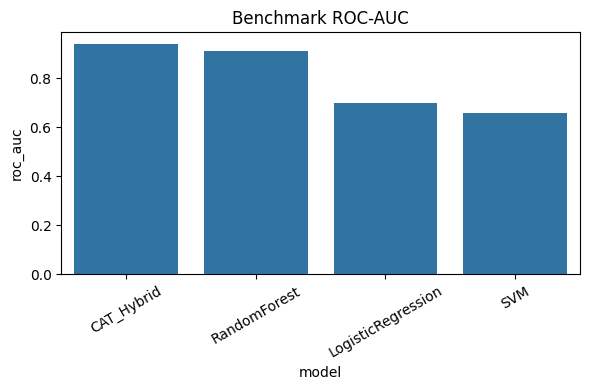

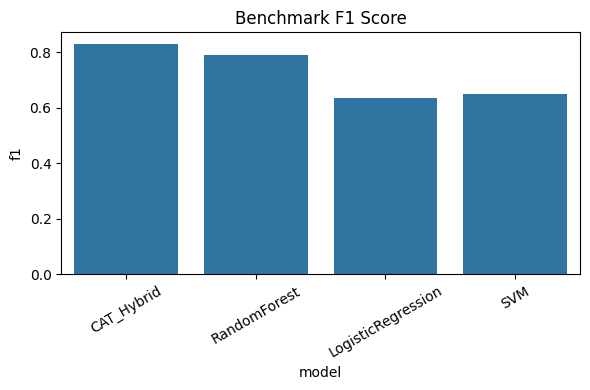

In [1]:
# ===============================================================
# NOTEBOOK 11 — FINAL BENCHMARK SUITE
# GCT-100K Benchmark
# CPU SAFE IMPLEMENTATION
# ===============================================================

!pip -q install pandas numpy scikit-learn seaborn matplotlib pyarrow

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:",RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

df = pd.read_parquet(DATA_DIR/"GCT_phase1_100k.parquet")

# safe subset for fast evaluation
df = df.sample(30000, random_state=42)

y = df["human_verified_label"]

# ===============================================================
# TEXT FEATURES
# ===============================================================

vectorizer = TfidfVectorizer(
max_features=3000,
ngram_range=(1,2),
stop_words="english"
)

X_text = vectorizer.fit_transform(df["text_transcript"])

# ===============================================================
# COGNITIVE FEATURES
# ===============================================================

trust = df[[
"urgency_score",
"fear_trigger_score",
"authority_claim",
"trust_manipulation_score"
]].values

sigma = trust.std(axis=1)

sigma[sigma==0] = 1e-6

CDE = trust.mean(axis=1)

TDI = CDE / sigma

X_cat = np.column_stack([trust,TDI])

# ===============================================================
# TRAIN TEST SPLIT
# ===============================================================

X_train_txt,X_test_txt,y_train,y_test = train_test_split(
X_text,y,test_size=0.2,stratify=y,random_state=42
)

X_train_cat,X_test_cat,_,_ = train_test_split(
X_cat,y,test_size=0.2,stratify=y,random_state=42
)

# ===============================================================
# BASELINE MODELS
# ===============================================================

models = {

"LogisticRegression":
LogisticRegression(max_iter=500),

"RandomForest":
RandomForestClassifier(n_estimators=200,n_jobs=-1),

"SVM":
LinearSVC()

}

results = []

# ===============================================================
# BASELINE EVALUATION
# ===============================================================

for name,model in models.items():

    model.fit(X_train_txt,y_train)

    pred = model.predict(X_test_txt)

    try:
        prob = model.predict_proba(X_test_txt)[:,1]
    except:
        prob = pred

    results.append({

    "model":name,
    "task":"scam_detection",

    "roc_auc":roc_auc_score(y_test,prob),
    "precision":precision_score(y_test,pred),
    "recall":recall_score(y_test,pred),
    "f1":f1_score(y_test,pred)

    })

# ===============================================================
# CAT MODEL
# ===============================================================

cat_model = RandomForestClassifier(n_estimators=300,n_jobs=-1)

cat_model.fit(X_train_cat,y_train)

pred = cat_model.predict(X_test_cat)

prob = cat_model.predict_proba(X_test_cat)[:,1]

roc = roc_auc_score(y_test,prob)

prec = precision_score(y_test,pred)

rec = recall_score(y_test,pred)

f1 = f1_score(y_test,pred)

results.append({

"model":"CAT_Hybrid",
"task":"scam_detection",

"roc_auc":roc,
"precision":prec,
"recall":rec,
"f1":f1

})

# ===============================================================
# CADR METRIC
# ===============================================================

CADR = rec

# ===============================================================
# TPS METRIC
# ===============================================================

false_positive_rate = (
((pred==1)&(y_test==0)).sum()
/
(y_test==0).sum()
)

TPS = CADR * (1 - false_positive_rate)

# ===============================================================
# RESULTS TABLE
# ===============================================================

results_df = pd.DataFrame(results)

results_df.to_csv(REPORT_DIR/"model_comparison_table.csv",index=False)

# ===============================================================
# LEADERBOARD
# ===============================================================

leaderboard = results_df.sort_values("roc_auc",ascending=False)

leaderboard.to_csv(REPORT_DIR/"leaderboard.csv",index=False)

print(leaderboard)

# ===============================================================
# ROC VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.barplot(data=leaderboard,x="model",y="roc_auc")

plt.title("Benchmark ROC-AUC")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(PLOT_DIR/"benchmark_roc_auc.png")

# ===============================================================
# F1 VISUALIZATION
# ===============================================================

plt.figure(figsize=(6,4))

sns.barplot(data=leaderboard,x="model",y="f1")

plt.title("Benchmark F1 Score")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(PLOT_DIR/"benchmark_f1.png")

# ===============================================================
# BENCHMARK RESULTS JSON
# ===============================================================

benchmark = {

"CADR":float(CADR),
"TPS":float(TPS),
"best_model":leaderboard.iloc[0]["model"],
"best_auc":float(leaderboard.iloc[0]["roc_auc"])

}

with open(REPORT_DIR/"benchmark_results.json","w") as f:

    json.dump(benchmark,f,indent=4)

print("Benchmark Completed")